In [4]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import joblib
import numpy as np
import pandas
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
with open("../data/intents.json", "r") as f:
    data = json.load(f)

sentences = []
labels = []

for intent in data["intents"]:
    for pattern in intent["patterns"]:
        sentences.append(pattern)
        labels.append(intent["tag"])

print(f"Loaded {len(sentences)} training examples across {len(set(labels))} intents.")

Loaded 20 training examples across 5 intents.


In [6]:
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(sentences).toarray()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

input_size = X_train.shape[1]
hidden_size = 64
output_size = len(label_encoder.classes_)

print(f"Input size: {input_size}, Output size: {output_size}")


Input size: 23, Output size: 5


In [7]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNet, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        out = self.softmax(out)
        return out

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = NeuralNet(input_size, hidden_size, output_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 100

train_losses = []
test_accuracies = []


In [9]:
for epoch in tqdm(range(epochs)):
    model.train()
    inputs = torch.tensor(X_train, dtype=torch.float32).to(device)
    targets = torch.tensor(y_train, dtype=torch.long).to(device)

    outputs = model(inputs)
    loss = criterion(outputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Evaluate every few epochs
    if (epoch+1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            test_inputs = torch.tensor(X_test, dtype=torch.float32).to(device)
            test_targets = torch.tensor(y_test, dtype=torch.long).to(device)
            test_outputs = model(test_inputs)
            _, predicted = torch.max(test_outputs, 1)
            acc = accuracy_score(test_targets.cpu(), predicted.cpu())
            test_accuracies.append(acc)
            print(f"Epoch [{epoch+1}/{epochs}]  Loss: {loss.item():.4f}  Test Acc: {acc:.3f}")


100%|██████████| 100/100 [00:00<00:00, 347.77it/s]

Epoch [10/100]  Loss: 1.5999  Test Acc: 0.000
Epoch [20/100]  Loss: 1.5894  Test Acc: 0.000
Epoch [30/100]  Loss: 1.5777  Test Acc: 0.000
Epoch [40/100]  Loss: 1.5636  Test Acc: 0.000
Epoch [50/100]  Loss: 1.5461  Test Acc: 0.000
Epoch [60/100]  Loss: 1.5239  Test Acc: 0.000
Epoch [70/100]  Loss: 1.4958  Test Acc: 0.000
Epoch [80/100]  Loss: 1.4605  Test Acc: 0.000
Epoch [90/100]  Loss: 1.4163  Test Acc: 0.000
Epoch [100/100]  Loss: 1.3631  Test Acc: 0.250


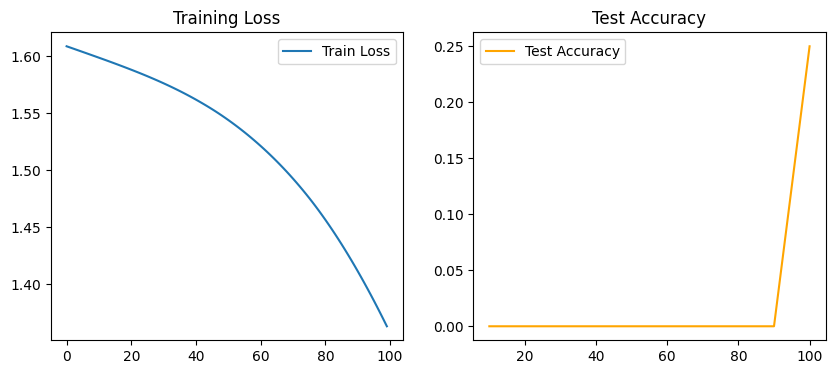

In [10]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.title("Training Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(np.arange(10, epochs+1, 10), test_accuracies, label='Test Accuracy', color='orange')
plt.title("Test Accuracy")
plt.legend()
plt.show()


In [11]:
MODEL_PATH = "../models/intent_model.pt"
TFIDF_PATH = "../models/tfidf.joblib"
LABEL_PATH = "../models/labels.json"

torch.save({
    "input_size": input_size,
    "hidden_size": hidden_size,
    "output_size": output_size,
    "model_state": model.state_dict()
}, MODEL_PATH)

joblib.dump(vectorizer, TFIDF_PATH)

with open(LABEL_PATH, "w") as f:
    json.dump({i: label for i, label in enumerate(label_encoder.classes_)}, f)

print("✅ Model, TF-IDF, and labels saved successfully!")

✅ Model, TF-IDF, and labels saved successfully!


In [12]:
def predict_intent(text):
    model.eval()
    X_input = vectorizer.transform([text]).toarray()
    X_tensor = torch.tensor(X_input, dtype=torch.float32).to(device)
    with torch.no_grad():
        output = model(X_tensor)
        probs = output.cpu().numpy()[0]
        top_idx = np.argmax(probs)
        return label_encoder.classes_[top_idx], float(probs[top_idx])

test_texts = ["hello", "play some music", "bye", "what’s the weather today"]
for t in test_texts:
    intent, conf = predict_intent(t)
    print(f"{t} → {intent} ({conf:.2f})")

hello → goodbye (0.30)
play some music → play_music (0.35)
bye → goodbye (0.50)
what’s the weather today → weather (0.46)
